In [ ]:
#I want to be able to take a all the data for a given cell and temperature and retrieve a dataset of densities and the detunings they were measured at. 
#data should be returned in an array of points (detuning, density)

In [2]:
#All my imports go here
import pandas as pd
import numpy as np

from density_app.functions.data_files import batchProcessFiles, file_path_traverse
from fnmatch import fnmatch
from density_app.functions.fitting_and_error import linear_fit_data_with_error, density_error, get_parabolic_fit, get_parabola_extrema, get_density_error_from_parabolic_fit, get_extended_xs
from density_app.functions.alkali_density_calculation import get_main_prefactor, get_first_order_terms_prefactor, get_second_order_terms_prefactor, get_first_order_terms, get_second_order_terms, rb_density_second_order
from density_app.functions.formatting import formatter
from density_app.functions.conversions import convertTtoKelvin

import matplotlib.pyplot as plt

#from density_app.functions.constants import LIGHT_SPEED

In [ ]:
#This module takes a root directory, finds all the data files and experiment settings files and creates a processed data file for each data set

path = "/Users/eleanor/Desktop/Data4Eleanor/Test"
batchProcessFiles(path) #creates processed files if none exist for a given raw data file contained within the directory located at path

{'/Users/eleanor/Desktop/Data4Eleanor/Test/80C_779.758nm/2024-09-23': ['/Users/eleanor/Desktop/Data4Eleanor/Test/80C_779.758nm/2024-09-23/Experiment_Params_2024-09-23.csv', '/Users/eleanor/Desktop/Data4Eleanor/Test/80C_779.758nm/2024-09-23/2024-09-23_cell-314A_temp-80_trial-1.csv', '/Users/eleanor/Desktop/Data4Eleanor/Test/80C_779.758nm/2024-09-23/Calibration_2024-09-23.csv'], '/Users/eleanor/Desktop/Data4Eleanor/Test/80C_779.791nm/2024-09-23': ['/Users/eleanor/Desktop/Data4Eleanor/Test/80C_779.791nm/2024-09-23/Experiment_Params_2024-09-23.csv', '/Users/eleanor/Desktop/Data4Eleanor/Test/80C_779.791nm/2024-09-23/2024-09-23_cell-314A_temp-80_trial-1.csv', '/Users/eleanor/Desktop/Data4Eleanor/Test/80C_779.791nm/2024-09-23/2024-09-23_cell-314A_temp-80_trial-1_processed.csv', '/Users/eleanor/Desktop/Data4Eleanor/Test/80C_779.791nm/2024-09-23/Calibration_2024-09-23.csv']}
unable to create processed file for  /Users/eleanor/Desktop/Data4Eleanor/Test/80C_779.791nm/2024-09-23


In [16]:
#This module is creating the dataset of densities and corresponding detunings

#THIS IS FOR CELL 314A
cell = '314A'
d2_orig = 7.80034e-5
d2_adjust = -0.00005e-5
d1_resonance = 7.94768e-5 #cm
d2_resonance = d2_orig+d2_adjust #cm
optical_path = 3.7 #cm
verdet_adjustment = 0 #we do not want to include any adjustment right now

wl_error = 0.00003e-5
d2_error = 0.00003e-5
d1_error = 0#.00003e-5

length = 3.7
length_error = 0.005

def get_density_vs_probe(root):
    data_file_str = '*_processed*'
    experiment_file_str = '*Experiment_Params*' 
    #traverse the root directory to collect wavelengths
    #get list of all csv files
    files = file_path_traverse(root)
    density_data = pd.DataFrame({'ProbeWavelength':[], 'Density':[], 'DensityError':[]})

    for key, value in files.items():
            #for each key I need to create one processed file
            processed = ''
            exp = ''
            #experiment_params = {}
            for v in value:
                if fnmatch(v, data_file_str):
                    processed = v #locates the data file in the set of files indexed under the current key
                if fnmatch(v, experiment_file_str):
                    exp = v #locates the data file in the set of files indexed under the current key
                #processed_data = pd.read_csv(processed)
            experiment_params = pd.read_csv(exp)
            probe_wavelength = (experiment_params['LaserWavelength'].to_numpy()[0]*10**(-7))
            temperature = experiment_params['OvenTemperature'].to_numpy()[0]
            #get the magnetic field data (x), the rotations (y) and the error from the data file
            data = pd.read_csv(processed)
            #convert to density values
            x = data['Magnetic Field (Gauss)'].to_numpy()
            y = data['Rotation (Radians)'].to_numpy()
            error = data['Rotation Standard Deviation'].to_numpy()
            param, cov = linear_fit_data_with_error(x,y,error)
            slope = param[0]
            slope_error = np.sqrt(cov[0][0])
            #put it in a dataframe
            #calculate error 
            rb_density = rb_density_second_order(d1_resonance, d2_resonance, optical_path, probe_wavelength, temperature, slope)
            total_error = np.sqrt(((wl_error+d2_error)/(d2_resonance-probe_wavelength))**2+(slope_error/slope)**2+((wl_error+d1_error)/(d1_resonance-probe_wavelength))**2)*rb_density
            total_error2 = density_error(slope_error, slope, length_error, length, wl_error, probe_wavelength, d1_error, d1_resonance, d2_error, d2_resonance, temperature)
            new_row = pd.DataFrame({'ProbeWavelength':[probe_wavelength], 'Density': [rb_density], 'DensityError':[total_error2], 'PercentError':[(total_error2/rb_density)*100]})
            density_data = pd.concat([density_data, new_row], ignore_index=True) 
        
    return density_data

def get_true_density(data_set, d2_res):
    x = data_set['ProbeWavelength'].to_numpy()-d2_res
    y = data_set['Density'].to_numpy()
    error = data_set['DensityError'].to_numpy()
    my_fit, cv = get_parabolic_fit(x, y, error)
    #get the true density value by taking the minimum of my fit
    min_wl, min_den = get_parabola_extrema(my_fit)
    rb_den_final_error = get_density_error_from_parabolic_fit(cv)
    return my_fit, min_den, rb_den_final_error

def get_verdet_adjustment(data_set, d1_res, d2_res, optical_length, temperature):
    x = data_set['ProbeWavelength'].to_numpy()
    y = data_set['Density'].to_numpy()
    error = data_set['DensityError'].to_numpy()
    my_fit, cv = get_parabolic_fit(x-d2_res, y, error)
    x_line = get_extended_xs(x-d2_res, 100, .1)
    y_line = my_fit(x_line)
    x_line2 = x_line+d2_res#get_extended_xs(x, 100, .1)
    min_wl, min_den = get_parabola_extrema(my_fit)
    diffs = y_line-min_den
    F = get_main_prefactor(optical_length)*(get_first_order_terms_prefactor(x_line2)*get_first_order_terms(d1_res, d2_res, x_line2)+get_second_order_terms_prefactor(x_line2, temperature)*get_second_order_terms(d1_res, d2_res, x_line2, False))
    vs = F*diffs
    print(vs)
    V = np.average(vs)
    return V

def get_data(data_set):
    x = data_set['ProbeWavelength'].to_numpy()
    y = data_set['Density'].to_numpy()
    error = data_set['DensityError'].to_numpy()
    return x,y,error
     
    
         
    

dir_80 = '/Users/eleanor/Desktop/Data4Eleanor/80C'
dir_90 = '/Users/eleanor/Desktop/Data4Eleanor/90C'
dir_110 = '/Users/eleanor/Desktop/Data4Eleanor/110C'
dir_120 = '/Users/eleanor/Desktop/Data4Eleanor/120C'

density_80C = get_density_vs_probe(dir_80)
density_90C = get_density_vs_probe(dir_90)
density_110C = get_density_vs_probe(dir_110)
density_120C = get_density_vs_probe(dir_120)

print(density_120C)
#print(density_120C['ProbeWavelength'].to_numpy())

    ProbeWavelength       Density  DensityError  PercentError
0          0.000078  2.199334e+13  3.092876e+12     14.062787
1          0.000078  2.290882e+13  3.201367e+12     13.974389
2          0.000078  2.057329e+13  2.870272e+12     13.951445
3          0.000078  2.043735e+13  2.855169e+12     13.970351
4          0.000078  2.276455e+13  3.192684e+12     14.024805
5          0.000078  2.070739e+13  2.891197e+12     13.962151
6          0.000078  2.077113e+13  2.899081e+12     13.957257
7          0.000078  2.042169e+13  2.848679e+12     13.949281
8          0.000078  1.958601e+13  2.734650e+12     13.962266
9          0.000078  2.068892e+13  2.885663e+12     13.947865
10         0.000078  2.097858e+13  2.930153e+12     13.967358
11         0.000078  2.732087e+13  3.824141e+12     13.997145
12         0.000078  1.947683e+13  2.716457e+12     13.947123
13         0.000078  2.148704e+13  3.005370e+12     13.986893
14         0.000078  2.287593e+13  3.197708e+12     13.978484
15      

           2
5.882e+27 x + 1.658e+18 x + 3.316e+12


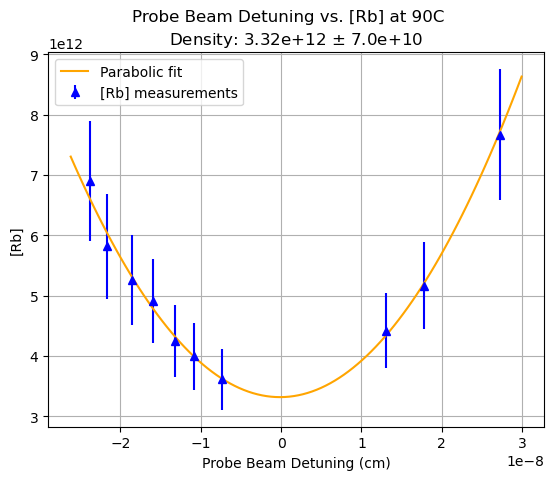

[Rb]:  3315960993218.373
[4.084138828944529e-06 4.08300737820288e-06 4.081832377893805e-06
 4.080610778837472e-06 4.079339243567365e-06 4.078014111436556e-06
 4.076631358580832e-06 4.07518655169894e-06 4.073674794673751e-06
 4.072090666560875e-06 4.0704281493351535e-06 4.068680543420852e-06
 4.066840368372226e-06 4.064899245767147e-06 4.06284776026912e-06
 4.060675294172739e-06 4.058369829151427e-06 4.055917707446006e-06
 4.0533033425405504e-06 4.050508866208862e-06 4.047513695236362e-06
 4.04429399542634e-06 4.040822013417016e-06 4.0370652367289154e-06
 4.032985327977208e-06 4.028536759407191e-06 4.023665044328964e-06
 4.018304419577194e-06 4.012374769459258e-06 4.005777484543977e-06
 3.998389799097697e-06 3.990056912148111e-06 3.980580810069788e-06
 3.9697040585050675e-06 3.957085708447742e-06 3.942264446115628e-06
 3.924600345727893e-06 3.903179181378355e-06 3.876647858720816e-06
 3.842915257440153e-06 3.7985698740042162e-06 3.7376431567675405e-06
 3.6486644293350887e-06 3.506437496

In [ ]:
#Plot stuff

from density_app.functions.fitting_and_error import get_extended_xs, get_parabolic_fit, get_parabola_extrema, get_density_error_from_parabolic_fit
from density_app.functions.alkali_density_calculation import get_main_prefactor, get_first_order_terms_prefactor, get_second_order_terms_prefactor, get_first_order_terms, get_second_order_terms, killian_density


def plot_parabola(data_set, d2_resonance, temperature):
    x = data_set['ProbeWavelength'].to_numpy()-d2_resonance
    y = data_set['Density'].to_numpy()
    error = data_set['DensityError'].to_numpy()


    #figure setup
    fig = plt.figure()
    ax = fig.add_subplot()
    fig.subplots_adjust(top=0.89)

    my_fit, cv = get_parabolic_fit(x, y, error)

    #plot the data sets
    ax.errorbar(x=x, y=y, yerr=error, color='blue', marker='^', linestyle='none', label = '[Rb] measurements')
    #plot the parabolic fit
    polyline = get_extended_xs(x, 100, .1)
    ax.plot(polyline, my_fit(polyline), color='orange', label = 'Parabolic fit') 

    #get the true density value by taking the minimum of my fit
    min_wl, min_den = get_parabola_extrema(my_fit)
    min_density_fmt = formatter(min_den, 2)
    rb_den_final_error = get_density_error_from_parabolic_fit(cv)
    rb_den_final_error_fmt = formatter(rb_den_final_error, 1)
    den_text = "Density: "+min_density_fmt+r" $ \pm $ "+rb_den_final_error_fmt

    #set up labels, titles, grid
    fig.suptitle("Probe Beam Detuning vs. [Rb] at %dC"%(temperature))
    ax.set_title(den_text)
    ax.legend()
    ax.set_xlabel("Probe Beam Detuning (cm)")
    ax.set_ylabel("[Rb]")
    ax.grid(visible=True, which='both', axis='both')

    #Print out Density info, for easy copypasting if necessary
    #print("Alkali Metal Density: ", min_density_fmt)
    #print("Density Error: ", rb_den_final_error_fmt)
    print(my_fit)
    #display the plot
    plt.show()

#actual density should be a flat line at the minimum
#want to know the difference between the fit and the minimum and also the points and the minimum

T=90
data = density_90C
plot_parabola(data, d2_resonance, T)

fit, rb, err = get_true_density(data, d2_resonance)
print("[Rb]: ", rb)
print("Verdet adjustment: ", get_verdet_adjustment(data, d1_resonance, d2_resonance, 3.7, T))
print("Killian: ",killian_density(T))

In [12]:
print(formatter(killian_density(140), 3))

6.204e+13


(42272496.4856796 - 2.78725751021706e+17*x)*(x - 7.80029e-5)**4*(x**2*((x - 7.80029e-5)**2 - 1.32540444754929e-8) + x*(1.95351361524288e-14 - 7.36949999999993e-7*(x - 7.80029e-5)**2) + 3.80166711749993e-12*(x - 7.80029e-5)**2)**2/(x*(x**3*(-1.31991260376874e-13*x + 1.99171295404854e-5*(x - 7.80029e-5)**3 + 1.02957010840512e-17) + x**2*(1.94541918669472e-19*x - 1.46779286148606e-11*(x - 7.80029e-5)**3 - 1.5174833827783e-23) + x*(x - 7.80029e-5)**2*(7.57182964490498e-17*x + 3.66948215371515e-12*(x - 7.80029e-5)**2 - 1.03177206040822e-19) - 3.78591482245249e-17*(x - 7.80029e-5)**4))
3.942096316259466e-06


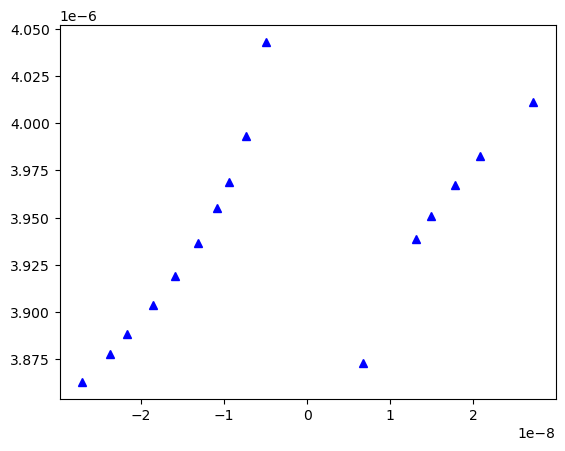

In [21]:
import sympy

from density_app.functions.constants import LIGHT_SPEED, PLANKS_CONSTANT, ELECTRON_MASS, ELECTRON_CHARGE, BOHR_MAGNETON, BOLTZMANN_CONSTANT

c = LIGHT_SPEED
h = PLANKS_CONSTANT
m = ELECTRON_MASS
q = ELECTRON_CHARGE
u = BOHR_MAGNETON
k = BOLTZMANN_CONSTANT

d2_orig = 7.80034e-5
d2_adjust = -0.00005e-5
d1 = 7.94768e-5 #cm
d2 = d2_orig+d2_adjust #cm
delta1 = d1-d2


x, y = sympy.symbols('x y')
#x is the difference between the probe beam and the resonant frequency

T=120

pref_0 = get_main_prefactor(3.7)
pref_1 = 1/(3*c**2)
pref_2 = -h/(k*c*T)

expr1 = 4*(d2-x)**4/delta1**2 + 7*(d2-x)**4/x**2 - 2*(d2-x)**4/(delta1*x)
expr2 = (d2-x)**2/delta1 - (d2-x)**2/x

F = 1/(pref_0*((pref_1*expr1)+(pref_2*expr2)))
derivativeF = sympy.diff(F)

parabola_derivative = 2*5.621e+27*x - 1.705e+18

V_eff = parabola_derivative/derivativeF


xs, ys, errors = get_data(density_120C)
xs = xs - d2

 #figure setup
fig = plt.figure()
ax = fig.add_subplot()
fig.subplots_adjust(top=0.89)

V_eff_simp = sympy.simplify(V_eff)
print(V_eff_simp)
ys = np.zeros(len(xs))
for i in range(0,len(xs)):
    ys[i] = V_eff_simp.subs(x, xs[i])

print(np.average(ys))

#plot the data sets
ax.errorbar(x=xs, y=ys, color='blue', marker='^', linestyle='none', label = '[Rb] measurements')
plt.show()


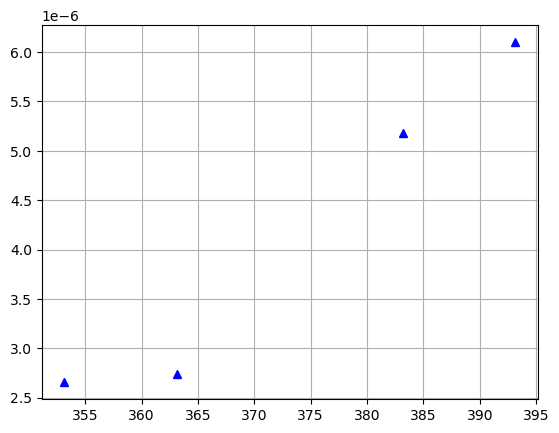

[2.65639391e-06 2.74005854e-06 5.18364205e-06 6.10208747e-06]
[353.15 363.15 383.15 393.15]
8.614233899564182e-08


In [144]:
l_verdet = 1.5
V = np.array([3.984590858153052e-06, 4.110087812936339e-06, 7.775463073431774e-06, 9.15313119789156e-06])/l_verdet
T = convertTtoKelvin(np.array([80, 90, 110, 120]))

#figure setup
fig = plt.figure()
ax = fig.add_subplot()
fig.subplots_adjust(top=0.89)
#plot the data sets
ax.errorbar(x=T, y=V, color='blue', marker='^', linestyle='none', label = '[Rb] measurements')
ax.grid(visible=True, which='both', axis='both')

plt.show()

rise = V[3]-V[0]
run = T[3]-T[0]
m = rise/run
print(V)
print(T)
print(m)